In [1]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.special import factorial, gamma, digamma, ellipk, ellipe, hyp2f1
from scipy.integrate import quad
from numpy import vectorize
import time as time

## Fox $H$-functions - power series
Here, we describe how to compute each of the three Fox $H$-functions that allows to describe the gNFW as a gravitational lens. In particular, we do this by means of their power series representations.

### Recursive implementation

#### $H^{2,1}_{2,2\,\Sigma}\left(x^2,n\right)$ (Surface mass density)

In [2]:
# Fox H-function power series (Surface mass density)
def SMDh(x, n, tol, N_max = 10000000):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    N_max : maximun number of iterations
    """
    
    sk =  np.ones(4)
    ck =  np.ones(4)
    
    if 0 < x**2 < 1: 
        a1k = gamma((n - 1)/2)*gamma(n/2)
        a2k = 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)
        aux  = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))
        ck[0] = aux
        sk[0] = aux 
        

        for k in range(1, N_max):
            a1k *= (2*k + n - 3)*(2*k + n -2)/(4*k**2)
            a2k += 2/k - 2/(2*k + n - 3) - 2/(2*k + n -2)

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))*x**(2*k)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]


    if x**2 > 1:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/gamma(n/2)
        a4k = gamma(n)*gamma(n/2)/gamma((n + 1)/2)
        aux = 0.5*(np.abs(x)*a3k - a4k)/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux
        
        for k in range(1, N_max):
            a3k *= (2*k + n - 3)**2/(2*k*(2*k - 1))
            a4k *= (2*k + n - 2)**2/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = 0.5*((np.abs(x)*a3k - a4k)*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux
            
            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]

In [3]:
# "Fast" computation (Surface mass density)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Coefficients ak

def SMDh_coef(n, N):
    """
    n: profile
    N : number of terms to be evaluated
    """
    
    ak = np.zeros((4,N))

    ak[0][0] = gamma((n - 1)/2)*gamma(n/2)
    ak[1][0] = 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)

    ak[2][0] = gamma(n - 1)*gamma((n - 1)/2)/gamma(n/2)
    ak[3][0] = gamma(n)*gamma(n/2)/gamma((n + 1)/2)

    for i in range(1, N):
        ak[0][i] = ak[0][i - 1]*(2*i + n - 3)*(2*i + n -2)/(4*i**2)
        ak[1][i] = ak[1][i - 1] + 2/i - 2/(2*i + n - 3) - 2/(2*i + n -2)
    
        ak[2][i] = ak[2][i - 1]*(2*i + n - 3)**2/(2*i*(2*i - 1))
        ak[3][i] = ak[3][i - 1]*(2*i + n - 2)**2/(2*i*(2*i + 1))

    return ak 

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Power series

def SMDh_f(x, n, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    ak: coefficients SMDh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2**(n-3)/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2**(n-3)/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2**(n-3)/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return 0.5*np.sum((np.abs(x)*ak[2] - ak[3])*(x**(-2*k)))/(np.abs(x)**(n + 1))
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return 0.5*np.sum((np.abs(x)*ak[2][:201] - ak[3][:201])*(x**(-2*k)))/(np.abs(x)**(n + 1))
    if x**2 >= 1.5:
        k = k[:51]
        return 0.5*np.sum((np.abs(x)*ak[2][:51] - ak[3][:51])*(x**(-2*k)))/(np.abs(x)**(n + 1))
    if x**2 == 1:
        return gamma(n-1)**2/(2**(n - 1)*gamma(n - 1/2))

#### $H^{2,2}_{3,3\,M}\left(x^2,n\right)$ (Projected mass)

In [4]:
# Fox H-function power series (Projected mass)
def PMh(x, n, tol, N_max = 1000000000):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    N_max : maximun number of iterations
    """
    
    sk =  np.ones(4)
    ck =  np.ones(4)
    
    if 0 < x**2 < 1: 
        a1k = gamma((n - 1)/2)*gamma(n/2)
        a2k = 1 + 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)
        aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a1k *= (2*k + n - 3)*(2*k + n -2)/(4*k*(k + 1))
            a2k += 1/k + 1/(k + 1) - 2/(2*k + n - 3) - 2/(2*k + n - 2)

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))*x**(2*k)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]

    # n > 2 and non-integer
    if x**2 > 1 and type(n) != int:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n))
        a4k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n))
        aux = (np.abs(x)*a3k - a4k)/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a3k *= (2*k + n - 3)*(2*k + n - 5)/(2*k*(2*k - 1))
            a4k *= (2*k + n - 2)*(2*k + n - 4)/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = ((np.abs(x)*a3k - a4k)*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + 2*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n = 3 
    if x**2 > 1 and n == 3:
        a3k = np.sqrt(np.pi)/2
        a4k = 2/np.sqrt(np.pi)
        aux = (a3k - np.abs(x)*a4k)/(np.abs(x)**6)
        ck[0] = aux
        sk[0] = aux

        for k in range(2, N_max):
            a3k *= (2*k - 1)/(2*k)
            a4k *= 2*(k - 1)/(2*k - 1)

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = ((a3k - np.abs(x)*a4k)*(x**(-2*k)))/(x**4)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + np.sqrt(np.pi)/(x**4) + 2*np.log(np.abs(x)/2)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n > 3 and even 
    if x**2 > 1 and n > 3 and n % 2 == 0:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n))
        a4k = gamma(n - 1)*gamma(n/2 - 1)/gamma((n - 1)/2)
        aux = a3k/(np.abs(x)**n)
        ck[0] = aux
        sk[0] = aux
        
        for k in range(1, int(n/2)):
            """
            Here we perform the first summation up to n/2 - 1 (first term of the second summation).    
            """
            a3k *= (2*k + n - 3)*(2*k + n - 5)/(2*k*(2*k - 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (a3k*(x**(-2*k)))/(np.abs(x)**n)
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = a4k/(np.abs(x)**(n + 1)) # Here we add the first term of the second sum, evaluated at k = n/2-1
        ck[0] = aux
        sk[0] += aux

        for k in range(int(n/2), N_max):
            """
            Here we continue the first summation from n/2, and start off the second sumation from this very same value since we have alreary 
            added the first term of the sequence given for k = n/2 - 1.
            """
            a3k *= (2*k + n - 3)*(2*k + n - 5)/(2*k*(2*k - 1))
            a4k *= 4*k*(k - 1)/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (a3k*(x**(-2*k)))/(np.abs(x)**n) + np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + 2*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n > 3 and odd
    if x**2 > 1 and n > 3 and n % 2 == 1:
        a3k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n))
        a4k = gamma(n - 2)*gamma((n - 3)/2)/gamma(n/2 - 1)
        aux = -a3k/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, int((n - 1)/2)):
            """
            Here we perform the first sumation up to (n - 3)/2 (first term of the second summation).    
            """
            a3k *= (2*k + n - 2)*(2*k + n - 4)/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = -a4k/(np.abs(x)**n) # Here we add the first term of the second sum, evaluated at k = (n - 3)/2
        ck[0] = aux
        sk[0] += aux

        for k in range(int((n - 1)/2), N_max):
            """
            Here we continue the first summation from (n - 1)/2, and start off the second summation from this very same value since we have 
            alreary added the first term of the sequence given for k = (n - 3)/2.
            """
            a3k *= (2*k + n - 2)*(2*k + n - 4)/(2*k*(2*k + 1))
            a4k *= 4*k*(k - 1)/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1)) - np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] +  2*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3)

In [5]:
# "Fast" computation (Projected mass)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Coefficients ak

def PMh_coef(n, N):
    """
    n: profile
    N : number of terms to be evaluated
    """
    
    ak = np.zeros((4,N))
    
    ak[0][0] = gamma((n - 1)/2)*gamma(n/2)
    ak[1][0] = 1 + 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)
    
    if n == 3:
        ak[2][0] = np.sqrt(np.pi)

        ak[0][1] = ak[0][0]*3/4
        ak[1][1] = ak[1][0] + 1/2 - 2/3
        ak[2][1] = np.sqrt(np.pi)/2
        ak[3][1] = 2/np.sqrt(np.pi)

        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k)*(2*k + 1)/(4*k*(k + 1))
            ak[1][k] = ak[1][k - 1] + 1/(k + 1) - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(2*k - 1)/(2*k)
            ak[3][k] = ak[3][k - 1]*2*(k - 1)/(2*k - 1)

    if n == 3.5:
        ak[2][0] = -2*gamma(5/2)*gamma(5/4)/(gamma(7/4))
        ak[3][0] = -2*gamma(7/2)*gamma(7/4)/(3*gamma(9/4))

        for k in range(1, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 0.5)*(2*k + 1.5)/(4*k*(k + 1))
            ak[1][k] = ak[1][k - 1] + 1/k + 1/(k + 1) - 2/(2*k + 0.5) - 2/(2*k + 1.5)
            
            ak[2][k] = ak[2][k - 1]*(2*k + 0.5)*(2*k - 1.5)/(2*k*(2*k - 1))
            ak[3][k] = ak[3][k - 1]*(2*k + 1.5)*(2*k - 0.5)/(2*k*(2*k + 1))

    if n == 4:
        ak[2][0] = -np.sqrt(np.pi)

        ak[0][1] = ak[0][0]*3/2
        ak[1][1] = ak[1][0] + 1 - 2/3
        ak[2][1] = ak[2][0]*3/2
        ak[3][1] = 4/np.sqrt(np.pi)
         
        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 1)/(2*k)
            ak[1][k] = ak[1][k - 1] + 1/k - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(2*k + 1)/(2*k)
            ak[3][k] = ak[3][k - 1]*2*k/(2*k - 1)
    return ak 

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Power series
    
# NFW
def PMh_f_nfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients PMh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = 2*np.log(np.abs(x)/2)/(np.sqrt(np.pi)*np.abs(x)**3)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((ak[2] - np.abs(x)*ak[3])*(x**(-2*k)))/(x**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((ak[2][:201] - np.abs(x)*ak[3][:201])*(x**(-2*k)))/(x**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((ak[2][:51] - np.abs(x)*ak[3][:51])*(x**(-2*k)))/(x**4) + aux

# super-NFW
def PMh_f_snfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients PMh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = 2/np.abs(x)**3
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((np.abs(x)*ak[2] - ak[3])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((np.abs(x)*ak[2][:201] - ak[3][:201])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((np.abs(x)*ak[2][:51] - ak[3][:51])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux

# Hernquist
def PMh_f_h(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients PMh_f
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """
    aux = 2/(np.sqrt(np.pi)*np.abs(x)**3)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((ak[2] + np.abs(x)*ak[3])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((ak[2][:201] + np.abs(x)*ak[3][:201])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((ak[2][:51] + np.abs(x)*ak[3][:51])*(x**(-2*k)))/(np.abs(x)**4) + aux

#### $H^{2,3}_{4,4\,\psi}\left(x^2,n\right)$ (Deflection potential)

In [6]:
# Fox H-function power series (Deflection potential)
def DPh(x, n, tol, N_max = 1000000000):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    N_max : maximun number of iterations
    """
    
    sk = np.ones(4)
    ck = np.ones(4)
    
    if 0 < x**2 < 1: 
        a1k = gamma((n - 1)/2)*gamma(n/2)
        a2k = 2*digamma(2) - digamma((n - 1)/2) - digamma(n/2)
        aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a1k *= (2*k + n - 3)*(2*k + n -2)/(4*(k + 1)**2)
            a2k += 2/(k + 1) - 2/(2*k + n - 3) - 2/(2*k + n - 2)
            
            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))*x**(2*k)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]

    # n > 2 and non-integer
    if x**2 > 1 and type(n) != int:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n)**2)
        a4k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n)**2)
        aux = 2*(np.abs(x)*a3k - a4k)/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a3k *= (2*k + n - 5)**2/(2*k*(2*k - 1))
            a4k *= (2*k + n - 4)**2/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = 2*((np.abs(x)*a3k - a4k)*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + (4*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(n - 3) - digamma(1))

    # n = 3 
    if x**2 > 1 and n == 3:
        a3k = np.sqrt(np.pi)/12
        a4k = 2/np.sqrt(np.pi)
        aux = (-4*a3k + np.abs(x)*a4k)/(np.abs(x)**6)
        ck[0] = aux
        sk[0] = aux

        for k in range(2, N_max):
            a3k *= (1 - 2*k)**2/(2*k*(1 + 2*k))
            a4k *= 2*(k - 1)**2/(k*(2*k - 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = ((-4*a3k + np.abs(x)*a4k)*(x**(-2*k)))/(x**4)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] - 2*np.sqrt(np.pi)/(x**4) + 2*(np.pi**2/4 + np.log(np.abs(x)/2)**2)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n > 3 and even 
    if x**2 > 1 and n > 3 and n % 2 == 0:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n)**2)
        a4k = 4*gamma(n - 1)*gamma(n/2)/(gamma((n - 1)/2)*(n - 2)**2)
        aux = 2*a3k/(np.abs(x)**n)
        ck[0] = aux
        sk[0] = aux

        for k in range(1, int(n/2)):
            """
            Here we perform the first summation up to n/2 - 1 (first term of the second summation).    
            """
            a3k *= (2*k + n - 5)**2/(2*k*(2*k - 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2*a3k*(x**(-2*k)))/(np.abs(x)**n)
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = -a4k/(np.abs(x)**(n + 1)) # Here we add the first term of the second sum, evaluated at k = n/2-1
        ck[0] = aux
        sk[0] += aux

        for k in range(int(n/2), N_max):
            """
            Here we continue the first summation from n/2, and start off the second sumation from this very same value since we have alreary 
            added the first term of the sequence given for k = n/2 - 1.
            """
            a3k *= (2*k + n - 5)**2/(2*k*(2*k - 1))
            a4k *= 4*(k - 1)**2/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2*a3k*(x**(-2*k)))/(np.abs(x)**n) - np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + (4*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(n - 3) - digamma(1))

    # n > 3 and odd
    if x**2 > 1 and n > 3 and n % 2 == 1:     
        a3k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n)**2)
        a4k = 4*gamma(n - 2)*gamma((n - 1)/2)/(gamma(n/2 - 1)*(n - 3)**2)
        aux = -2*a3k/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, int((n - 1)/2)):
            """
            Here we perform the first sumation up to (n - 3)/2 (first term of the second summation).    
            """
            a3k *= (2*k + n - 4)**2/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -2*(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = a4k/(np.abs(x)**n) # Here we add the first term of the second sum, evaluated at k = (n - 3)/2
        ck[0] = aux
        sk[0] += aux

        for k in range(int((n - 1)/2), N_max):
            """
            Here we continue the first summation from (n - 1)/2, and start off the second summation from this very same value since we have 
            alreary added the first term of the sequence given for k = (n - 3)/2.
            """
            a3k *= (2*k + n - 4)**2/(2*k*(2*k + 1))
            a4k *= 4*(k - 1)**2/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -2*(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1)) + np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + (4*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(n - 3) - digamma(1))

In [7]:
# "Fast" computation (Deflection potential)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Coefficients ak

def DPh_coef(n, N):
    """
    n: profile
    N : number of terms to be evaluated
    """
    
    ak = np.zeros((4,N))

    ak[0][0] = gamma((n - 1)/2)*gamma(n/2)
    ak[1][0] = 2*digamma(2) - digamma((n - 1)/2) - digamma(n/2)
    
    if n == 3:
        ak[2][0] = np.sqrt(np.pi)/2

        ak[0][1] = ak[0][0]*3/8
        ak[1][1] = ak[1][0] - 2/3
        ak[2][1] = np.sqrt(np.pi)/12
        ak[3][1] = 2/np.sqrt(np.pi)

        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k)*(2*k + 1)/(4*(k + 1)**2)
            ak[1][k] = ak[1][k - 1] + 2/(k + 1) - 1/k - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(1 - 2*k)**2/(2*k*(1 + 2*k))
            ak[3][k] = ak[3][k - 1]*2*(k - 1)**2/(k*(2*k - 1))

    if n == 3.5:
        ak[2][0] = 4*gamma(5/2)*gamma(5/4)/(gamma(7/4))
        ak[3][0] = 4*gamma(7/2)*gamma(7/4)/(9*gamma(9/4))

        for k in range(1, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 0.5)*(2*k + 1.5)/(4*(k + 1)**2)
            ak[1][k] = ak[1][k - 1] + 2/(k + 1) - 2/(2*k + 0.5) - 2/(2*k + 1.5)
            
            ak[2][k] = ak[2][k - 1]*(2*k - 1.5)**2/(2*k*(2*k - 1))
            ak[3][k] = ak[3][k - 1]*(2*k - 0.5)**2/(2*k*(2*k + 1))

    if n == 4:
        ak[2][0] = np.sqrt(np.pi)

        ak[0][1] = ak[0][0]*3/4
        ak[1][1] = ak[1][0] + 1/2 - 2/3
        ak[2][1] = ak[2][0]*1/2
        ak[3][1] = 4/np.sqrt(np.pi)
        
        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 1)/(2*(k + 1))
            ak[1][k] = ak[1][k - 1] + 1/(k + 1) - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(2*k - 1)/(2*k)
            ak[3][k] = ak[3][k - 1]*2*(k - 1)/(2*k - 1)
    return ak 

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Power series

# NFW
def DPh_f_nfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients DPh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = 2*(np.pi**2/4 + np.log(np.abs(x)/2)**2)/(np.sqrt(np.pi)*np.abs(x)**3)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((-4*ak[2] + np.abs(x)*ak[3])*(x**(-2*k)))/(x**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((-4*ak[2][:201] + np.abs(x)*ak[3][:201])*(x**(-2*k)))/(x**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((-4*ak[2][:51] + np.abs(x)*ak[3][:51])*(x**(-2*k)))/(x**4) + aux

# super-NFW
def DPh_f_snfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients DPh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """
    
    aux = (4/(np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(0.5) - digamma(1))
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return 2*np.sum((np.abs(x)*ak[2] - ak[3])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return 2*np.sum((np.abs(x)*ak[2][:201] - ak[3][:201])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return 2*np.sum((np.abs(x)*ak[2][:51] - ak[3][:51])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux

# Hernquist
def DPh_f_h(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients DPh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = (4/(np.sqrt(np.pi)*np.abs(x)**3))*np.log(np.abs(x)/2)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((2*ak[2] - np.abs(x)*ak[3])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((2*ak[2][:201] - np.abs(x)*ak[3][:201])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((2*ak[2][:51] - np.abs(x)*ak[3][:51])*(x**(-2*k)))/(np.abs(x)**4) + aux

## Final analytical expressions

Here, we express the Fox $H$-functions of interest in terms of the Gauss hypergeometric function.

In [8]:
# Auxiliarly functions

def f0(x, n):
    if 0 < x**2 < 1:
        return hyp2f1((n - 1)/2, n /2, n - 1/2, 1 - x**2)
    if x**2 > 1:
        return hyp2f1(n - 1, n - 1, n - 1/2, 0.5*(np.abs(x)-1)/np.abs(x))/(np.abs(x)**(n-1))
    if x**2 == 1: 
        return 1

def f1(x, n):
    if 0 < x**2 < 1:
        return hyp2f1((n - 3)/2, n/2 - 1, n - 3/2, 1 - x**2)
    if x**2 > 1:
        return hyp2f1(n - 3, n - 1, n - 3/2, 0.5*(np.abs(x)-1)/np.abs(x))/(np.abs(x)**(n-3))
    if x**2 == 1: 
        return 1
        
def f2(x, n):
    if 0 < x**2 < 1:
        return hyp2f1((n - 3)/2, n/2 - 1, n - 1/2, 1 - x**2)
    if x**2 > 1:
        return hyp2f1(n - 3, n + 1, n - 1/2, 0.5*(np.abs(x)-1)/np.abs(x))/(np.abs(x)**(n-3))
    if x**2 == 1: 
        return 1

def f3(x):
    if 0 < x**2 < 1:
        aux = np.sqrt(1 - x**2)
        return np.log(np.abs(x)/2) + np.arctanh(aux)/aux
    if x**2 > 1:
        aux = np.sqrt(x**2 - 1)
        return np.log(np.abs(x)/2) + np.arctan(aux)/aux
    if x**2 == 1: 
        return 1 - np.log(2)
        
def f4(x):
    if 0 < x**2 < 1:
        arg = np.sqrt(1 - x**2)
        return np.log(np.abs(x)/2)**2 - np.arctanh(arg)**2
    if x**2 > 1:
        arg = np.sqrt(x**2 - 1)
        return np.log(np.abs(x)/2)**2 + np.arctan(arg)**2
    if x**2 == 1: 
        return np.log(2)**2

In [9]:
# Fox H-function  (Surface mass density)
def SMDh_a(x, n):
    amp = gamma(n - 1)**2/(2**(n - 1)*gamma(n - 1/2)*np.abs(x))
    return amp*f0(x,n)

# Fox H-function  (Projected mass)
def PMh_a(x, n):
    if n != 3:
        amp1 = 2*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3)
        amp2 = gamma(n - 1)*gamma(n - 3)/(2**(n - 3)*gamma(n - 3/2)*np.abs(x)**3)
        return amp1 - amp2*f1(x ,n)
    if n == 3:
        amp = 2/(np.sqrt(np.pi)*np.abs(x)**3)
        return amp*f3(x)

# Fox H-function  (Deflection potential)
def DPh_a(x, n):
    if n != 3:
        amp1 = (4*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(n-3) - digamma(1))
        amp2 = gamma(n - 3)**2/(2**(n - 4)*gamma(n - 3/2)*np.abs(x)**5)

        return amp1 + amp2*(((2*n - 3)*x**2 - 2)*f1(x, n) + (n*(n - 1)*(1 - x**2)/(2*n - 3))*f2(x, n))
    if n == 3:
        amp = 2/(np.sqrt(np.pi)*np.abs(x)**3)
        return amp*f4(x)

In [10]:
# Lensing properties

# Surface mass density
def SMDensity(x, n, smd0):
    return smd0*x*SMDh_a(x, n)

# Projected mass density
def PMass(x, n, r0, smd0):
    return np.pi*smd0*(r0**2)*(x**3)*PMh_a(x, n)

# Deflection potential
def DPotential(x, n, k0):
    return 0.5*k0*(x**3)*DPh_a(x, n)
# Shear
def Shear(x, n, k0):
    return k0*x*(PMh_a(x, n) - SMDh_a(x, n))

# Mean shear
def MShear(x, n, k0):
    return k0*x*(DPh_a(x, n) - PM_a(x, n))

# Deflection angle
def DAngle(x, n, k0):
    if x != 0:
        return k0*(np.abs(x)**3)*PMh_a(x, n)/x
    if x == 0:
        return 0

# Vectorized functions
smd_f = vectorize(SMDensity, otypes=[float], cache = True)
pm_f  = vectorize(PMass, otypes=[float], cache = True)
dp_f  = vectorize(DPotential, otypes=[float], cache = True)
s_f   = vectorize(Shear, otypes=[float], cache = True)
ms_f  = vectorize(MShear, otypes=[float], cache = True)
da_f  = vectorize(DAngle, otypes=[float], cache = True)

## Simplified expressions

Here, for the particular case of the NFW, sNFW, and Hernquist lenses, we provide the simplified expressions for the different lensing properties. We also include those of the Non-Singular Isothermal Sphere (NIS).

In [11]:
# Profiles
# n = 0:   NIS
# n = 3:   NFW
# n = 3.5: sNFW
# n = 4:   Hernquist

# Surface mass density (Simplified)
def SMDensity_sim(x, n, smd0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = smd0/np.sqrt(np.pi)
        if x == 1: 
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(1/(x**2 - 1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(1/(x**2 - 1))*(1 - np.arccos(1/x)/arg)
    #sNFW
    if n == 3.5:
        arg = (1-x)/(1+x)
        if x == 1:
            return smd0*9*np.pi/(128*np.sqrt(2))
        if x != 1:
            return smd0*(((3 + x)*ellipk(arg) - 4*ellipe(arg))/(2*(1-x)**2*(1 + x)**(3/2)))
        
    #Hernquist
    if n == 4:
        amp = smd0/np.sqrt(np.pi)
        if x == 1: 
            return 4*amp/15
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccosh(1/x) - 3)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccos(1/x) - 3)

    #NIS
    if n == 0:
        return smd0*np.sqrt(np.pi)/np.sqrt(1 + x**2)

# Projected mass (Simplified)
def PMass_sim(x, n, r0, smd0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = 2*np.sqrt(np.pi)*r0**2*smd0
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 + np.log(0.5))
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(np.log(0.5*x) + np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(np.log(0.5*x) + np.arccos(1/x)/arg)
    #sNFW
    if n == 3.5:
        amp = 2*np.pi*r0**2*smd0
        arg = (1 - x)/(1 + x)
        if x == 0:
            return 0.
        if x == 1:
            return amp*(1 - 3*np.pi/(8*np.sqrt(2)))
        if x>0 and x != 1:
            return amp*(((ellipe(arg) - x*ellipk(arg))/(np.sqrt(1 + x)*(x - 1))) + 1)
    #Hernquist
    if n == 4:
        amp = 2*np.sqrt(np.pi)*r0**2*smd0
        if x == 0:
            return 0
        if x == 1:
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1. - x**2)
            return (amp*x**2/(x**2 -1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp*x**2/(x**2 -1))*(1 - np.arccos(1/x)/arg)

    #NIS
    if n == 0:
        if x == 0:
            return 0
        else:
            return 2*(np.pi**1.5)*(r0**2)*smd0*(np.sqrt(1 + x**2) - 1)
    
# Deflection potential (Simplified)
def DPotential_sim(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*np.log(2)**2
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*((np.log(0.5*x))**2 - (np.arccosh(1/x))**2)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*((np.log(0.5*x))**2 + (np.arccos(1/x))**2)
    #sNFW
    if n == 3.5:
        if x == 0:
            return 0
        if x > 0:
            arg = (1-x)/(1+x)
            return 2*(k0)*(2*ellipk(arg)/np.sqrt(1 + x) + np.log(x/8))
    #Hernquist
    if n == 4:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 - np.log(2))
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(np.log(0.5*x) + np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(np.log(0.5*x) + np.arccos(1/x)/arg)

    #NIS
    if n == 0:
        return 2*np.sqrt(np.pi)*k0*(np.sqrt(1 + x**2) - np.log(0.5*(np.sqrt(1 + x**2) + 1)) - 1)
        

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

# Convergence (Simplified)
def Convergence_sim(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(1/(x**2 - 1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(1/(x**2 - 1))*(1 - np.arccos(1/x)/arg)
            
    #sNFW
    if n == 3.5:
        arg = (1 - x)/(1 + x)
        if x == 1:
            return k0*9*np.pi/(128*np.sqrt(2))
        if x != 1:
            return k0*(((3 + x)*ellipk(arg) - 4*ellipe(arg))/(2*(1 - x)**2*(1 + x)**(3/2)))
            
        
    #Hernquist
    if n == 4:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return 4*amp/15
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccosh(1/x) - 3)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccos(1/x) - 3)

    #NIS
    if n == 0:
        return k0*np.sqrt(np.pi)/np.sqrt(1 + x**2)


# Deflection angle (Simplified)
def DAngle_sim(x, n, k0):
    """
    x: dimensionless radius (position)
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 - np.log(2))
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccos(1/np.abs(x))/arg)
    #sNFW
    if n == 3.5:
        amp = 2*k0
        arg = (1 - np.abs(x))/(1 + np.abs(x))
        if x == 0:
            return 0.
        if np.abs(x) == 1:
            return amp*(1 - 3*np.pi/(8*np.sqrt(2)))
        if np.abs(x) > 0 and np.abs(x) != 1:
            return (amp/x)*(((ellipe(arg) - np.abs(x)*ellipk(arg))/(np.sqrt(1 + np.abs(x))*(np.abs(x) - 1))) + 1)
    
    #Hernquist
    if n == 4:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp/3
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1. - x**2)
            return (amp*x/(x**2 - 1))*(1 - np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp*x/(x**2 - 1))*(1 - np.arccos(1/np.abs(x))/arg)

    #NIS
    if n == 0:
        if x == 0:
            return 0
        else:
            return 2*np.sqrt(np.pi)*k0*(np.sqrt(1 + x**2) - 1)/x

# Shear (Simplified)
def Shear_sim(x, n, k0):
    """
    x >= 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    if x == 0 and n == 0:
        return 0
    if x == 0 and n != 0:
        return k0*gamma(n - 1)/(2*np.sqrt(np.pi))
    if x > 0:
        return DAngle_sim(x, n, k0)/x - Convergence_sim(x, n, k0)

# Mean shear (Simplified)
def MShear_sim(x, n, k0):
    """
    x >= 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    if x == 0 and n == 0:
        return 0
    if x == 0 and n != 0:
        return k0*gamma(n - 1)/(2*np.sqrt(np.pi))
    if x > 0:
        return 2*DPotential_sim(x, n, k0)/x**2 - DAngle_sim(x, n, k0)/x
        
# Vectorized functions
smd_sim = vectorize(SMDensity_sim, otypes=[float], cache = True)
pm_sim = vectorize(PMass_sim, otypes=[float], cache = True)
dp_sim = vectorize(DPotential_sim, otypes=[float], cache = True)
da_sim = vectorize(DAngle_sim, otypes=[float], cache = True)
c_sim = vectorize(Convergence_sim, otypes=[float], cache = True)
s_sim = vectorize(Shear_sim, otypes=[float], cache = True)
ms_sim = vectorize(MShear_sim, otypes=[float], cache = True)

# Numerical integration

In [12]:
# Volumetric mass density 
def MDensity(z, x, n, r0, smd0):
    arg = np.sqrt((z/r0)**2 + x**2) 
    return gamma(n - 1)*smd0/(2*np.sqrt(np.pi)*r0*arg*(1 + arg)**(n-1))

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Numerical integration
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

# Surface Mass Density  
def SMDensity_n(x, n, r0, smd0):
    return 2*quad(MDensity, 0, np.inf, args=(x, n, r0, smd0))[0]

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
"""
Here, when computing the projected mass and deflection potential, we assume that an anlytical expression for the surface mass density is
available. This makes the numerical integration faster. In particular, we use the surface mass density given in terms of the Gauss
hypergeometric function.
"""
#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
# Projected mass

# Integrand
def PMass_i(xp, n, smd0):
    return xp*SMDensity(xp, n, smd0)
    
def PMass_n(x, n, r0, smd0):
    return 2*np.pi*r0**2*quad(PMass_i, 0, x, args=(n, smd0))[0]

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
# Deflection potential

# Integrand
def DPotential_i(xp, x, n, smd0):
    return xp*SMDensity(xp, n, smd0)*np.log(x/xp)
    
def DPotential_n(x, n, smd0, smd_cr):
    return (2/smd_cr)*quad(DPotential_i, 0, x, args=(x, n, smd0))[0]

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
# Projected mass

# Integrand
def PMass_sim_i(xp, n, smd0):
    return xp*SMDensity_sim(xp, n, smd0)
    
def PMass_sim_n(x, n, r0, smd0):
    return 2*np.pi*r0**2*quad(PMass_sim_i, 0, x, args=(n, smd0))[0]

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
# Deflection potential

# Integrand
def DPotential_sim_i(xp, x, n, smd0):
    return xp*SMDensity_sim(xp, n, smd0)*np.log(x/xp)
    
def DPotential_sim_n(x, n, smd0, smd_cr):
    return (2/smd_cr)*quad(DPotential_sim_i, 0, x, args=(x, n, smd0))[0]


# Vectorized functions
smd_n = vectorize(SMDensity_n, otypes=[float], cache = True)
pm_n  = vectorize(PMass_n, otypes=[float], cache = True)
dp_n  = vectorize(DPotential_n, otypes=[float], cache = True)

## Performance and accuracy

### Number of terms computed

In [13]:
points = 10000
tol = 1e-15
n = 3

x1 = np.linspace(0.001, 0.999, points)
x2 = np.linspace(1.001, 1000, points)

n_max_smd1 = np.zeros(points)
n_max_smd2 = np.zeros(points)
n_max_pm1 = np.zeros(points)
n_max_pm2 = np.zeros(points)
n_max_dp1 = np.zeros(points)
n_max_dp2 = np.zeros(points)

for i in range(points):
    nm1, _ = SMDh(x1[i], n, tol)
    n_max_smd1[i] = nm1 
    nm2, _ = SMDh(x2[i], n, tol)
    n_max_smd2[i] = nm2
    
    nm3, _ = PMh(x1[i], n, tol)
    n_max_pm1[i] = nm3 
    nm4, _ = PMh(x2[i], n, tol)
    n_max_pm2[i] = nm4
    
    nm5, _ = DPh(x1[i], n, tol)
    n_max_dp1[i] = nm5 
    nm6, _ = DPh(x2[i], n, tol)
    n_max_dp2[i] = nm6

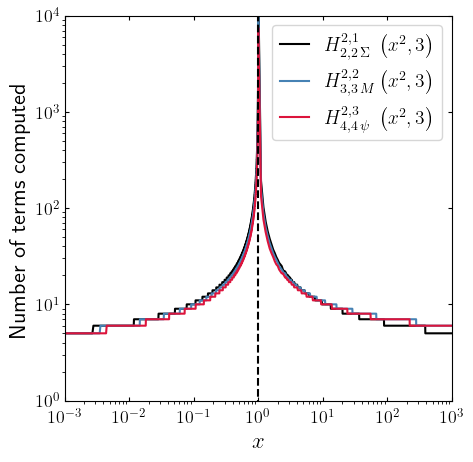

In [14]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16.5
ticks_s = 12.5
lc = 2

colortext = "white"
fig = plt.figure(figsize=(5,5))
ges = GridSpec(1, 1)
ax1 = fig.add_subplot(ges[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(x1, n_max_smd1, ls = "-", color  = "black", label = r"$H^{2,1}_{2,2\,\Sigma}\;\left(x^2,3\right)$")
ax1.plot(x2, n_max_smd2, ls = "-", color  = "black")

ax1.plot(x1, n_max_pm1, ls = "-", color  = "steelblue", label = r"$H^{2,2}_{3,3\,M}\left(x^2,3\right)$")
ax1.plot(x2, n_max_pm2, ls = "-", color  = "steelblue")

ax1.plot(x1, n_max_dp1, ls = "-", color  = "crimson", label = r"$H^{2,3}_{4,4\,\psi}\;\left(x^2,3\right)$")
ax1.plot(x2, n_max_dp2, ls = "-", color  = "crimson")

ax1.vlines(1, -10, 1000000, colors="black", linestyles='--', lw =1.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"Number of terms computed", fontsize=axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=1.03*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.tick_params(axis = "x", pad = 7)
#ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.4))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(0.001, 1000)
ax1.set_ylim(1,10000)
ax1.set_xscale("log")
ax1.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Legend
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.legend(loc='upper right', fontsize = 0.85*axis_fs, ncol = 1, handlelength = 1.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

plt.savefig("N.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

### Performance

In [15]:
"""
We evaluate each function (power series) multiple times (N_av), and take the averaga value (particularly for the computation time) in order
to reduce the random noise present in the calculations. Here, N_max is the maximum number of terms computed (particularly close to x = 1), in 
each power series and points represents how many points we evaluate each iteration. 
"""

N_av = 100 
N_max = 10000
points = 100
x = np.linspace(0.001, 5, points)

In [16]:
# NFW (series)

ys_nfw_smd = np.zeros(points)
ys_nfw_pm = np.zeros(points)
ys_nfw_dp = np.zeros(points)

ts_nfw_smd = np.zeros(points)
ts_nfw_pm = np.zeros(points)
ts_nfw_dp = np.zeros(points)

# Coefficients

ak_smd = SMDh_coef(3, N_max)
ak_pm = PMh_coef(3, N_max)
ak_dp = DPh_coef(3, N_max)

k = np.arange(0, N_max, 1)

for j in range(N_av):
    for i in range(points):
        t1_i = time.time()
        ys_nfw_smd[i] += x[i]*SMDh_f(x[i], 3, ak_smd, k)/N_av
        t1_f = time.time()
        ts_nfw_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        ys_nfw_pm[i] += np.pi*(x[i]**3)*PMh_f_nfw(x[i], ak_pm, k)/N_av
        t2_f = time.time()
        ts_nfw_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        ys_nfw_dp[i] += 0.5*(x[i]**3)*DPh_f_nfw(x[i], ak_dp, k)/N_av
        t3_f = time.time()
        ts_nfw_dp[i] += (t3_f - t3_i)/N_av

In [17]:
# sNFW (series)

ys_snfw_smd = np.zeros(points)
ys_snfw_pm = np.zeros(points)
ys_snfw_dp = np.zeros(points)

ts_snfw_smd = np.zeros(points)
ts_snfw_pm = np.zeros(points)
ts_snfw_dp = np.zeros(points)

# Coefficients

ak_smd = SMDh_coef(3.5, N_max)
ak_pm = PMh_coef(3.5, N_max)
ak_dp = DPh_coef(3.5, N_max)

k = np.arange(0, N_max, 1)

for j in range(N_av):
    for i in range(points):
        t1_i = time.time()
        ys_snfw_smd[i] += x[i]*SMDh_f(x[i], 3.5, ak_smd, k)/N_av
        t1_f = time.time()
        ts_snfw_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        ys_snfw_pm[i] += np.pi*(x[i]**3)*PMh_f_snfw(x[i], ak_pm, k)/N_av
        t2_f = time.time()
        ts_snfw_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        ys_snfw_dp[i] += 0.5*(x[i]**3)*DPh_f_snfw(x[i], ak_dp, k)/N_av
        t3_f = time.time()
        ts_snfw_dp[i] += (t3_f - t3_i)/N_av

In [18]:
# Hernquist (series)

ys_h_smd = np.zeros(points)
ys_h_pm = np.zeros(points)
ys_h_dp = np.zeros(points)

ts_h_smd = np.zeros(points)
ts_h_pm = np.zeros(points)
ts_h_dp = np.zeros(points)

# Coefficients

ak_smd = SMDh_coef(4, N_max)
ak_pm = PMh_coef(4, N_max)
ak_dp = DPh_coef(4, N_max)

k = np.arange(0, N_max, 1)


for j in range(N_av):
    for i in range(points):
        t1_i = time.time()
        ys_h_smd[i] += x[i]*SMDh_f(x[i], 4, ak_smd, k)/N_av
        t1_f = time.time()
        ts_h_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        ys_h_pm[i] += np.pi*(x[i]**3)*PMh_f_h(x[i], ak_pm, k)/N_av
        t2_f = time.time()
        ts_h_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        ys_h_dp[i] += 0.5*(x[i]**3)*DPh_f_h(x[i], ak_dp, k)/N_av
        t3_f = time.time()
        ts_h_dp[i] += (t3_f - t3_i)/N_av

In [19]:
# NFW (Analytical)

y_nfw_smd = np.zeros(points)
y_nfw_pm  = np.zeros(points)
y_nfw_dp  = np.zeros(points)

t_nfw_smd = np.zeros(points)
t_nfw_pm  = np.zeros(points)
t_nfw_dp  = np.zeros(points)

for j in range(N_av):
    for i in range(points):
        t1_i = time.time()
        y_nfw_smd[i] += SMDensity(x[i], 3, 1)/N_av
        t1_f = time.time()
        t_nfw_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        y_nfw_pm[i] += PMass(x[i], 3, 1, 1)/N_av
        t2_f = time.time()
        t_nfw_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        y_nfw_dp[i] += DPotential(x[i], 3, 1)/N_av
        t3_f = time.time()
        t_nfw_dp[i] += (t3_f - t3_i)/N_av

In [20]:
# sNFW (Analytical)

y_snfw_smd = np.zeros(points)
y_snfw_pm  = np.zeros(points)
y_snfw_dp  = np.zeros(points)

t_snfw_smd = np.zeros(points)
t_snfw_pm  = np.zeros(points)
t_snfw_dp  = np.zeros(points)

for j in range(N_av):
    for i in range(points):
        t1_i = time.time()
        y_snfw_smd[i] += SMDensity(x[i], 3.5, 1)/N_av
        t1_f = time.time()
        t_snfw_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        y_snfw_pm[i] += PMass(x[i], 3.5, 1, 1)/N_av
        t2_f = time.time()
        t_snfw_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        y_snfw_dp[i] += DPotential(x[i], 3.5, 1)/N_av
        t3_f = time.time()
        t_snfw_dp[i] += (t3_f - t3_i)/N_av

In [21]:
# Hernquist (Analytical)

y_h_smd = np.zeros(points)
y_h_pm  = np.zeros(points)
y_h_dp  = np.zeros(points)

t_h_smd = np.zeros(points)
t_h_pm  = np.zeros(points)
t_h_dp  = np.zeros(points)

for j in range(N_av):
    for i in range(points):
        t1_i = time.time()
        y_h_smd[i] += SMDensity(x[i], 4, 1)/N_av
        t1_f = time.time()
        t_h_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        y_h_pm[i] += PMass(x[i], 4, 1, 1)/N_av
        t2_f = time.time()
        t_h_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        y_h_dp[i] += DPotential(x[i], 4, 1)/N_av
        t3_f = time.time()
        t_h_dp[i] += (t3_f - t3_i)/N_av

In [22]:
# NFW (Numerical)

yn_nfw_smd = np.zeros(points)
yn_nfw_pm  = np.zeros(points)
yn_nfw_dp  = np.zeros(points)

tn_nfw_smd = np.zeros(points)
tn_nfw_pm  = np.zeros(points)
tn_nfw_dp  = np.zeros(points)
                     
for j in range(N_av):
    for i in range(points):
        t1_i = time.time()
        yn_nfw_smd[i] += SMDensity_n(x[i], 3, 1, 1)/N_av
        t1_f = time.time()
        tn_nfw_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        yn_nfw_pm[i] += PMass_n(x[i], 3, 1, 1)/N_av
        t2_f = time.time()
        tn_nfw_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        yn_nfw_dp[i] += DPotential_n(x[i], 3, 1, 1)/N_av
        t3_f = time.time()
        tn_nfw_dp[i] += (t3_f - t3_i)/N_av

In [23]:
# sNFW (Numerical)

yn_snfw_smd = np.zeros(points)
yn_snfw_pm  = np.zeros(points)
yn_snfw_dp  = np.zeros(points)

tn_snfw_smd = np.zeros(points)
tn_snfw_pm  = np.zeros(points)
tn_snfw_dp  = np.zeros(points)

for j in range(N_av):
    for i in range(points):
        # Surface mass density
        t1_i = time.time()
        yn_snfw_smd[i] += SMDensity_n(x[i], 3.5, 1, 1)/N_av
        t1_f = time.time()
        tn_snfw_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        yn_snfw_pm[i] += PMass_n(x[i], 3.5, 1, 1)/N_av
        t2_f = time.time()
        tn_snfw_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        yn_snfw_dp[i] += DPotential_n(x[i], 3.5, 1, 1)/N_av
        t3_f = time.time()
        tn_snfw_dp[i] += (t3_f - t3_i)/N_av

In [24]:
# Hernquist (Numerical)

yn_h_smd = np.zeros(points)
yn_h_pm  = np.zeros(points)
yn_h_dp  = np.zeros(points)

tn_h_smd = np.zeros(points)
tn_h_pm  = np.zeros(points)
tn_h_dp  = np.zeros(points)

for j in range(N_av):
    for i in range(points):
        # Surface mass density
        t1_i = time.time()
        yn_h_smd[i] += SMDensity_n(x[i], 4, 1, 1)/N_av
        t1_f = time.time()
        tn_h_smd[i] += (t1_f - t1_i)/N_av

        t2_i = time.time()
        yn_h_pm[i] += PMass_n(x[i], 4, 1, 1)/N_av
        t2_f = time.time()
        tn_h_pm[i] += (t2_f - t2_i)/N_av

        t3_i = time.time()
        yn_h_dp[i] += DPotential_n(x[i], 4, 1, 1)/N_av
        t3_f = time.time()
        tn_h_dp[i] += (t3_f - t3_i)/N_av

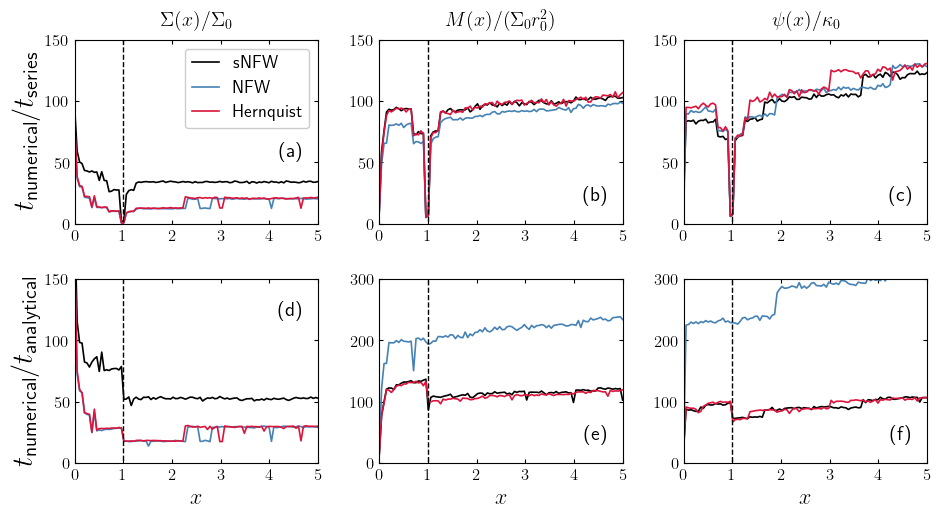

In [25]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
ls = 3
lc = 1.2

colortext = "white"
colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(11, 5.5))
#fig.suptitle(r"Controlling subplot sizes with width_ratios and height_ratios")

ges = GridSpec(2, 3,hspace=0.3, wspace=0.25)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])
ax3 = fig.add_subplot(ges[0,2])

ax4 = fig.add_subplot(ges[1,0])
ax5 = fig.add_subplot(ges[1,1])
ax6 = fig.add_subplot(ges[1,2])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#  Upper row

# Surface mass density
ax1.plot(x, tn_snfw_smd/ts_snfw_smd, ls='-', color = "black",  lw = lc, label = r"sNFW", alpha = 1)
ax1.plot(x, tn_nfw_smd/ts_nfw_smd, ls='-', color = "steelblue", lw = lc, label = r"NFW", alpha = 1)
ax1.plot(x, tn_h_smd/ts_h_smd, ls='-', color = "crimson",  lw = lc, label = r"Hernquist", alpha = 1)

ax1.vlines(1, -10, 100000, colors="black", linestyles='--', lw =1)

# Projected mass
ax2.plot(x, tn_snfw_pm/ts_snfw_pm, ls='-', color = "black", lw = lc, label = r"sNFW", alpha = 1)
ax2.plot(x, tn_nfw_pm/ts_nfw_pm, ls='-', color = "steelblue", lw = lc, label = r"NFW", alpha = 1)
ax2.plot(x, tn_h_pm/ts_h_pm, ls='-', color = "crimson",  lw = lc, label = r"Hernquist", alpha = 1)

ax2.vlines(1, -10, 100000, colors="black", linestyles='--', lw =1)

# Deflection potential
ax3.plot(x, tn_snfw_dp/ts_snfw_dp, ls='-', color = "black",  lw = lc, label = r"sNFW", alpha = 1)
ax3.plot(x, tn_nfw_dp/ts_nfw_dp, ls='-', color = "steelblue", lw = lc, label = r"NFW", alpha = 1)
ax3.plot(x, tn_h_dp/ts_h_dp, ls='-', color = "crimson", lw = lc, label = r"Hernquist", alpha = 1)

ax3.vlines(1, -10, 100000, colors="black", linestyles='--', lw =1)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
# Lower row

# Surface mass density
ax4.plot(x, tn_snfw_smd/t_snfw_smd, ls='-', color = "black",  lw = lc, label = r"sNFW", alpha = 1)
ax4.plot(x, tn_nfw_smd/t_nfw_smd, ls='-', color = "steelblue",  lw = lc, label = r"NFW", alpha = 1)
ax4.plot(x, tn_h_smd/t_h_smd, ls='-', color = "crimson",  lw = lc, label = r"Hernquist", alpha = 1)

ax4.vlines(1, -10, 100000, colors="black", linestyles='--', lw =1)

# Projected mass
ax5.plot(x, tn_snfw_pm/t_snfw_pm, ls='-', color = "black",  lw = lc, label = r"sNFW", alpha = 1)
ax5.plot(x, tn_nfw_pm/t_nfw_pm, ls='-', color = "steelblue",  lw = lc, label = r"NFW", alpha = 1)
ax5.plot(x, tn_h_pm/t_h_pm, ls='-', color = "crimson",  lw = lc, label = r"Hernquist", alpha = 1)

ax5.vlines(1, -10, 100000, colors="black", linestyles='--', lw =1)

# Deflection potential
ax6.plot(x, tn_snfw_dp/t_snfw_dp, ls='-', color = "black",  lw = lc, label = r"sNFW", alpha = 1)
ax6.plot(x, tn_nfw_dp/t_nfw_dp, ls='-', color = "steelblue", lw = lc, label = r"NFW", alpha = 1)
ax6.plot(x, tn_h_dp/t_h_dp, ls='-', color = "crimson",  lw = lc, label = r"Hernquist", alpha = 1)

ax6.vlines(1, -10, 100000, colors="black", linestyles='--', lw =1)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$t_{\text{numerical}}/t_{\text{series}}$", fontsize=1.3*axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(0, 5)
ax1.set_ylim(0, 150)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax2.set_xlabel(r"$x$", fontsize=axis_fs)
#ax2.set_ylabel(r"$I_{\text{NFW}}$", fontsize=axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax2.set_xlim(0.0, 5)
ax2.set_ylim(0, 150)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax3.set_xlabel(r"$x$", fontsize=axis_fs)
#ax3.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax3.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax3.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax3.set_xlim(0.0, 5)
ax3.set_ylim(0, 150)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax4.set_xlabel(r"$x$", fontsize=axis_fs)
ax4.set_ylabel(r"$t_{\text{numerical}}/t_{\text{analytical}}$", fontsize=1.3*axis_fs)
#ax4.set_title(r"$x$", fontsize=axis_fs)
ax4.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax4.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax4.set_xlim(0, 5)
ax4.set_ylim(0, 150)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax5.set_xlabel(r"$x$", fontsize=axis_fs)
#ax5.set_ylabel(r"$I_{\text{NFW}}$", fontsize=axis_fs)
#ax5.set_title(r"$x$", fontsize=axis_fs)
ax5.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax5.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax5.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax5.set_xlim(0.0, 5)
ax5.set_ylim(0, 300)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax6.set_xlabel(r"$x$", fontsize=axis_fs)
#ax6.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax6.set_title(r"$x$", fontsize=axis_fs)
ax6.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax6.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax6.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax6.set_xlim(0.0, 5)
ax6.set_ylim(0,300)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Text and legend
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_title(r"$\Sigma(x)/\Sigma_0$", fontsize=0.9*axis_fs, pad = 10)
ax2.set_title(r"$M(x)/(\Sigma_0r_0^2)$", fontsize=0.9*axis_fs, pad = 10)
ax3.set_title(r"$\psi(x)/\kappa_0$", fontsize=0.9*axis_fs, pad = 10)

ax1.text(4.7,55, r"(a)", horizontalalignment="right", fontsize = 0.9*axis_fs)
ax2.text(4.7,15, r"(b)", horizontalalignment="right", verticalalignment="bottom", fontsize = 0.9*axis_fs)
ax3.text(4.7,15, r"(c)", horizontalalignment="right", verticalalignment="bottom", fontsize = 0.9*axis_fs)

ax4.text(4.7,132, r"(d)", horizontalalignment="right", verticalalignment="top", fontsize = 0.9*axis_fs)
ax5.text(4.7,30, r"(e)", horizontalalignment="right", verticalalignment="bottom", fontsize = 0.9*axis_fs)
ax6.text(4.7,30, r"(f)", horizontalalignment="right", verticalalignment="bottom", fontsize = 0.9*axis_fs)

ax1.legend(loc='upper right', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

plt.savefig("performance.pdf", bbox_inches='tight', dpi = 300,transparent=True)
plt.show()

In [26]:
# Surface mass density

# Ratio of average computation time: <numerical>/<series>
print("sNFW surface mass density: <t_n>/<t_s> = ", np.average(tn_snfw_smd)/np.average(ts_snfw_smd))
print("NFW surface mass density: <t_n>/<t_s> = ", np.average(tn_nfw_smd)/np.average(ts_nfw_smd))
print("Hernquist surface mass density: <t_n>/<t_s> = ", np.average(tn_h_smd)/np.average(ts_h_smd))

print("*******************************")

# Ratio of average computation time: <numerical>/<analytical>
print("sNFW surface mass density: <t_n>/<t_a> = ", np.average(tn_snfw_smd)/np.average(t_snfw_smd))
print("NFW surface mass density: <t_n>/<t_a> = ", np.average(tn_nfw_smd)/np.average(t_nfw_smd))
print("Hernquist surface mass density: <t_n>/<t_a> = ", np.average(tn_h_smd)/np.average(t_h_smd))

sNFW surface mass density: <t_n>/<t_s> =  26.762592103816125
NFW surface mass density: <t_n>/<t_s> =  13.458883163096164
Hernquist surface mass density: <t_n>/<t_s> =  14.073356240695105
*******************************
sNFW surface mass density: <t_n>/<t_a> =  58.358603442147704
NFW surface mass density: <t_n>/<t_a> =  27.458172751757886
Hernquist surface mass density: <t_n>/<t_a> =  28.187026883380295


In [27]:
# Projected mass

# Ratio of average computation time: <numerical>/<series>
print("sNFW projected mass: <t_n>/<t_s> = ", np.average(tn_snfw_pm)/np.average(ts_snfw_pm))
print("NFW projected mass: <t_n>/<t_s> = ", np.average(tn_nfw_pm)/np.average(ts_nfw_pm))
print("Hernquist projected mass: <t_n>/<t_s> = ", np.average(tn_h_pm)/np.average(ts_h_pm))

print("*******************************")

# Ratio of average computation time: <numerical>/<analytical>
print("sNFW projected mass: <t_n>/<t_a> = ", np.average(tn_snfw_pm)/np.average(t_snfw_pm))
print("NFW projected mass: <t_n>/<t_a> = ", np.average(tn_nfw_pm)/np.average(t_nfw_pm))
print("Hernquist projected mass: <t_n>/<t_a> = ", np.average(tn_h_pm)/np.average(t_h_pm))

sNFW projected mass: <t_n>/<t_s> =  72.89573522977561
NFW projected mass: <t_n>/<t_s> =  69.02955695712345
Hernquist projected mass: <t_n>/<t_s> =  74.32289217833058
*******************************
sNFW projected mass: <t_n>/<t_a> =  114.60386135497178
NFW projected mass: <t_n>/<t_a> =  211.06014290568038
Hernquist projected mass: <t_n>/<t_a> =  111.1608938518212


In [28]:
# deflection potential

# Ratio of average computation time: <numerical>/<series>
print("sNFW deflection potential: <t_n>/<t_s> = ", np.average(tn_snfw_dp)/np.average(ts_snfw_dp))
print("NFW deflection potential: <t_n>/<t_s> = ", np.average(tn_nfw_dp)/np.average(ts_nfw_dp))
print("Hernquist deflection potential: <t_n>/<t_s> = ", np.average(tn_h_dp)/np.average(ts_h_dp))

print("*******************************")

# Ratio of average computation time: <numerical>/<analytical>
print("sNFW deflection potential: <t_n>/<t_a> = ", np.average(tn_snfw_dp)/np.average(t_snfw_dp))
print("NFW deflection potential: <t_n>/<t_a> = ", np.average(tn_nfw_dp)/np.average(t_nfw_dp))
print("Hernquist deflection potential: <t_n>/<t_a> = ", np.average(tn_h_dp)/np.average(t_h_dp))

sNFW deflection potential: <t_n>/<t_s> =  81.37032455784069
NFW deflection potential: <t_n>/<t_s> =  83.43116827993654
Hernquist deflection potential: <t_n>/<t_s> =  88.37198541036759
*******************************
sNFW deflection potential: <t_n>/<t_a> =  91.76614494141644
NFW deflection potential: <t_n>/<t_a> =  275.58569838046265
Hernquist deflection potential: <t_n>/<t_a> =  93.02151102540157


### Accuracy

In [29]:
"""
In this case we do not take any average, since the noise is persent in the computation time, not in the numerical value of
the function (computed by any means) itself.  Here, N_max is the maximum number of terms computed (particularly close to x = 1) in 
each power series, and points represents how many points we evaluate each iteration. 
"""
N_max = 50000
points = 100000

x = np.linspace(0.001, 1000, points)

dy_snfw_smd = np.zeros(points)
dy_snfw_pm = np.zeros(points)
dy_snfw_dp = np.zeros(points)

dy_nfw_smd = np.zeros(points)
dy_nfw_pm = np.zeros(points)
dy_nfw_dp = np.zeros(points)

dy_h_smd = np.zeros(points)
dy_h_pm = np.zeros(points)
dy_h_dp = np.zeros(points)

#Coefficients

ak_smd_nfw = SMDh_coef(3, N_max)
ak_pm_nfw = PMh_coef(3, N_max)
ak_dp_nfw = DPh_coef(3, N_max)

ak_smd_snfw = SMDh_coef(3.5, N_max)
ak_pm_snfw = PMh_coef(3.5, N_max)
ak_dp_snfw = DPh_coef(3.5, N_max)

ak_smd_h = SMDh_coef(4, N_max)
ak_pm_h = PMh_coef(4, N_max)
ak_dp_h = DPh_coef(4, N_max)

k = np.arange(0, N_max, 1)

for i in range(points):
    dy_nfw_smd[i] = np.abs((x[i]*SMDh_f(x[i], 3, ak_smd_nfw, k) - SMDensity_sim(x[i], 3, 1))/SMDensity_sim(x[i], 3, 1))
    dy_nfw_pm[i]  = np.abs((np.pi*(x[i]**3)*PMh_f_nfw(x[i], ak_pm_nfw, k) - PMass_sim(x[i], 3, 1, 1))/PMass_sim(x[i], 3, 1, 1))
    dy_nfw_dp[i]  = np.abs((0.5*(x[i]**3)*DPh_f_nfw(x[i], ak_dp_nfw, k) - DPotential_sim(x[i], 3, 1))/DPotential_sim(x[i], 3, 1))

    dy_snfw_smd[i] = np.abs((x[i]*SMDh_f(x[i], 3.5, ak_smd_snfw, k) - SMDensity_sim(x[i], 3.5, 1))/SMDensity_sim(x[i], 3.5, 1))
    dy_snfw_pm[i]  = np.abs((np.pi*(x[i]**3)*PMh_f_snfw(x[i], ak_pm_snfw, k) - PMass_sim(x[i], 3.5, 1, 1))/PMass_sim(x[i], 3.5, 1, 1))
    dy_snfw_dp[i]  = np.abs((0.5*(x[i]**3)*DPh_f_snfw(x[i], ak_dp_snfw, k) - DPotential_sim(x[i], 3.5, 1))/DPotential_sim(x[i], 3.5, 1))

    dy_h_smd[i] = np.abs((x[i]*SMDh_f(x[i], 4, ak_smd_h, k) - SMDensity_sim(x[i], 4, 1))/SMDensity_sim(x[i], 4, 1))
    dy_h_pm[i]  = np.abs((np.pi*(x[i]**3)*PMh_f_h(x[i], ak_pm_h, k) - PMass_sim(x[i], 4, 1, 1))/PMass_sim(x[i], 4, 1, 1))
    dy_h_dp[i]  = np.abs((0.5*(x[i]**3)*DPh_f_h(x[i], ak_dp_h, k) - DPotential_sim(x[i], 4, 1))/DPotential_sim(x[i], 4, 1))

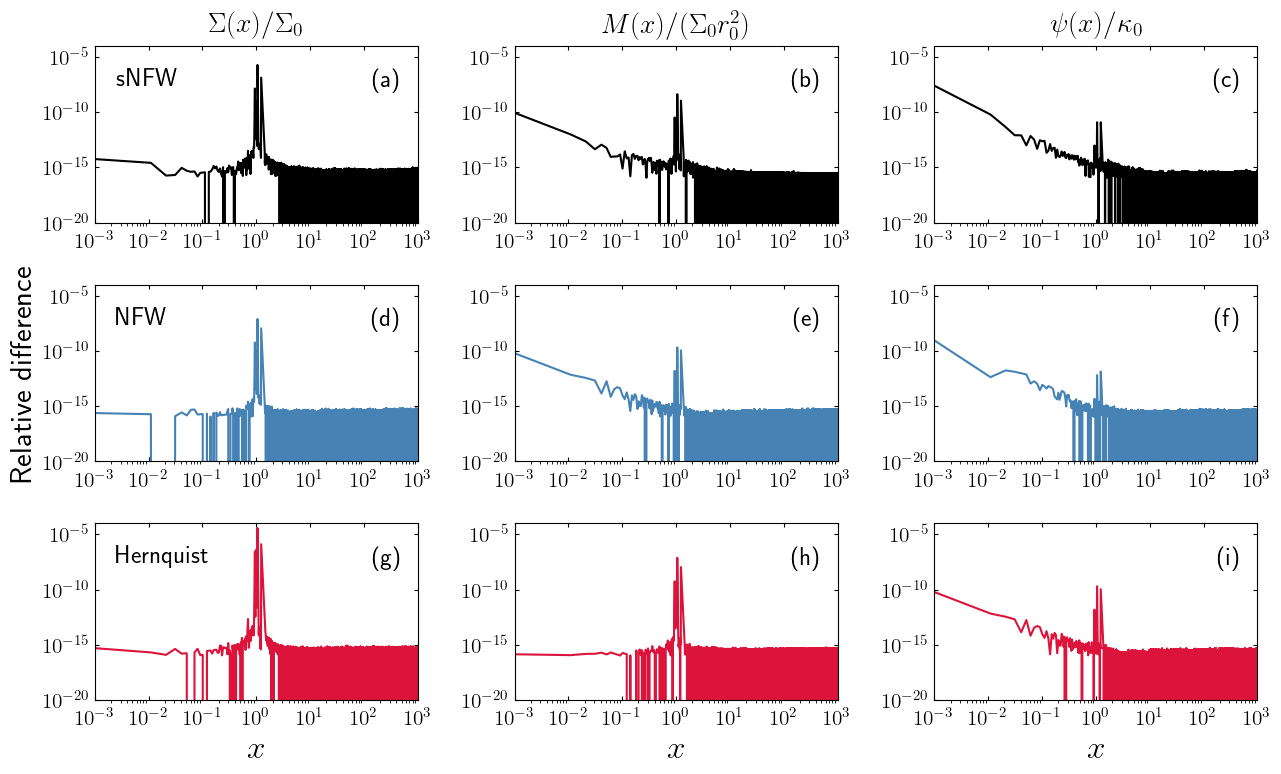

In [30]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 20
ticks_s = 14

colortext = "white"
colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(15, 8.5))
#fig.suptitle(r"Controlling subplot sizes with width_ratios and height_ratios")

ges = GridSpec(3, 3,hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])
ax3 = fig.add_subplot(ges[0,2])

ax4 = fig.add_subplot(ges[1,0])
ax5 = fig.add_subplot(ges[1,1])
ax6 = fig.add_subplot(ges[1,2])

ax7 = fig.add_subplot(ges[2,0])
ax8 = fig.add_subplot(ges[2,1])
ax9 = fig.add_subplot(ges[2,2])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

# Surface mass density
ax1.plot(x, dy_snfw_smd, ls='-', color = "black",  ms = 5, label = r"sNFW", alpha = 1)
ax4.plot(x, dy_nfw_smd, ls='-', color = "steelblue",  ms = 5, label = r"NFW", alpha = 1)
ax7.plot(x, dy_h_smd, ls='-', color = "crimson",  ms = 5, label = r"Hernquist", alpha = 1)

# Projected mass
ax2.plot(x, dy_snfw_pm, ls='-', color = "black",  ms = 5, label = r"sNFW", alpha = 1)
ax5.plot(x, dy_nfw_pm, ls='-', color = "steelblue",  ms = 5, label = r"NFW", alpha = 1)
ax8.plot(x, dy_h_pm, ls='-', color = "crimson",  ms = 5, label = r"Hernquist", alpha = 1)

# Deflection potential
ax3.plot(x, dy_snfw_dp, ls='-', color = "black",  ms = 5, label = r"sNFW", alpha = 1)
ax6.plot(x, dy_nfw_dp, ls='-', color = "steelblue",  ms = 5, label = r"NFW", alpha = 1)
ax9.plot(x, dy_h_dp, ls='-', color = "crimson",  ms = 3, label = r"Hernquist", alpha = 1)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#ax1.set_xlabel(r"$x_s =\xi/r_s$", fontsize=axis_fs)
#ax1.set_ylabel(r"Relative difference", fontsize=1.3*axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.tick_params(axis = "x", pad = 7)
#ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax1.set_xlim(0.001, 1000)
ax1.set_ylim(1e-20, 1e-4)
ax1.set_xscale("log")
ax1.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax2.set_xlabel(r"$x_s =\xi/r_s$", fontsize=axis_fs)
#ax2.set_ylabel(r"Relative difference", fontsize=axis_fs)
#ax2.set_title(r"Relative difference", fontsize=axis_fs)
ax2.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.tick_params(axis = "x", pad = 7)
#ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax2.set_xlim(0.001, 1000)
ax2.set_ylim(1e-20, 1e-4)
ax2.set_xscale("log")
ax2.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax3.set_xlabel(r"$x_s =\xi/r_s$", fontsize=axis_fs)
#ax3.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax3.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.tick_params(axis = "x", pad = 7)
#ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax3.set_xlim(0.001, 1000)
ax3.set_ylim(1e-20, 1e-4)
ax3.set_xscale("log")
ax3.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax4.set_xlabel(r"$x_s =\xi/r_s$", fontsize=axis_fs)
ax4.set_ylabel(r"Relative difference", fontsize=1.1*axis_fs)
#ax4.set_title(r"$x$", fontsize=axis_fs)
ax4.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax4.tick_params(axis = "x", pad = 7)
#ax4.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax4.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax4.set_xlim(0.001, 1000)
ax4.set_ylim(1e-20, 1e-4)
ax4.set_xscale("log")
ax4.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax5.set_xlabel(r"$x_s =\xi/r_s$", fontsize=axis_fs)
#ax5.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax5.set_title(r"$x$", fontsize=axis_fs)
ax5.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax5.tick_params(axis = "x", pad = 7)
#ax5.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax5.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax5.set_xlim(0.001, 1000)
ax5.set_ylim(1e-20, 1e-4)
ax5.set_xscale("log")
ax5.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax6.set_xlabel(r"$x_s =\xi/r_s$", fontsize=axis_fs)
#ax6.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax6.set_title(r"$x$", fontsize=axis_fs)
ax6.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax6.tick_params(axis = "x", pad = 7)
#ax6.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax6.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax6.set_xlim(0.001, 1000)
ax6.set_ylim(1e-20, 1e-4)
ax6.set_xscale("log")
ax6.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax7.set_xlabel(r"$x$", fontsize=1.2*axis_fs)
#ax7.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax7.set_title(r"$x$", fontsize=axis_fs)
ax7.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax7.tick_params(axis = "x", pad = 7)
#ax7.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax7.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax7.set_xlim(0.001, 1000)
ax7.set_ylim(1e-20, 1e-4)
ax7.set_xscale("log")
ax7.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax8.set_xlabel(r"$x$", fontsize=1.2*axis_fs)
#ax8.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax8.set_title(r"$x$", fontsize=axis_fs)
ax8.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax8.tick_params(axis = "x", pad = 7)
#ax8.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax8.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax8.set_xlim(0.001, 1000)
ax8.set_ylim(1e-20, 1e-4)
ax8.set_xscale("log")
ax8.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax9.set_xlabel(r"$x$", fontsize=1.2*axis_fs)
#ax9.set_ylabel(r"$I_{\text{H}}$", fontsize=axis_fs)
#ax9.set_title(r"$x$", fontsize=axis_fs)
ax9.tick_params(labelsize=1.1*ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax9.tick_params(axis = "x", pad = 7)
#ax9.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax9.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax9.set_xlim(0.001, 1000)
ax9.set_ylim(1e-20, 1e-4)
ax9.set_xscale("log")
ax9.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Text
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_title(r"$\Sigma(x)/\Sigma_0$", fontsize=1*axis_fs, pad = 10)
ax2.set_title(r"$M(x)/(\Sigma_0r_0^2)$", fontsize=1*axis_fs, pad = 10)
ax3.set_title(r"$\psi(x)/\kappa_0$", fontsize=1*axis_fs, pad = 10)

ax1.text(500,1e-6, r"(a)", horizontalalignment="right", verticalalignment="top", fontsize = 0.9*axis_fs)
ax2.text(500,1e-6, r"(b) ", horizontalalignment="right", verticalalignment="top",fontsize = 0.9*axis_fs)
ax3.text(500,1e-6, r"(c)", horizontalalignment="right", verticalalignment="top",fontsize = 0.9*axis_fs)

ax4.text(500,1e-6, r"(d)", horizontalalignment="right", verticalalignment="top", fontsize = 0.9*axis_fs)
ax5.text(500,1e-6, r"(e) ", horizontalalignment="right", verticalalignment="top",fontsize = 0.9*axis_fs)
ax6.text(500,1e-6, r"(f)", horizontalalignment="right", verticalalignment="top",fontsize = 0.9*axis_fs)

ax7.text(500,1e-6, r"(g)", horizontalalignment="right", verticalalignment="top", fontsize = 0.9*axis_fs)
ax8.text(500,1e-6, r"(h) ", horizontalalignment="right", verticalalignment="top",fontsize = 0.9*axis_fs)
ax9.text(500,1e-6, r"(i)", horizontalalignment="right", verticalalignment="top",fontsize = 0.9*axis_fs)

ax1.text(0.0025,1e-6, r"sNFW", horizontalalignment="left", verticalalignment="top", fontsize = 0.9*axis_fs)
ax4.text(0.0025,1e-6, r"NFW", horizontalalignment="left", verticalalignment="top",fontsize = 0.9*axis_fs)
ax7.text(0.0025,1e-6, r"Hernquist", horizontalalignment="left", verticalalignment="top",fontsize = 0.9*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
plt.savefig("performance_diff.pdf", bbox_inches='tight', dpi = 300, transparent=True)

plt.show()